In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
df=pd.read_csv('bank-additional-full.csv',sep=';')
df['y'].head()

0    no
1    no
2    no
3    no
4    no
Name: y, dtype: object

In [3]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [4]:
df['y']=df['y'].map({'yes':1,'no':0})
df=pd.get_dummies(df,columns=['job','marital','education','default','housing','loan','contact','month','day_of_week','poutcome'],drop_first=True)
df['contacted']=(df['pdays']==999).astype(int)
df['pdays']=df['pdays'].replace(999,0)

In [5]:
heat_matrix=np.zeros((3,4))
df['y'].head()

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [6]:
X=df.drop('y',axis=1)
y=df['y']

In [7]:
X_tr,X_ts,y_tr,y_ts=train_test_split(X,y,test_size=0.1,random_state=42,stratify=y)

In [8]:
sc=StandardScaler()
X_TR=sc.fit_transform(X_tr)
X_TS=sc.transform(X_ts)

In [9]:
accy=0
target_C=0
target_gamma=0
cnt=0
C_list=[0.1,1,10]
gamma_list=[0.001,0.01,0.05,0.1]
for i,c in enumerate(C_list):
    for j,g in enumerate(gamma_list):
        md=SVC(kernel='rbf',C=c,gamma=g)
        md.fit(X_TR,y_tr)
        y_pd=md.predict(X_TS)
        paccy=accuracy_score(y_ts,y_pd)
        heat_matrix[i,j]=paccy
        cnt=cnt+1
        print('已完成训练',cnt,'组')
        if paccy>accy:
            accy=paccy
            target_C=c
            target_gamma=g
print('C=',target_C,'gamma=',target_gamma,'时，准确度最高，最高为',accy*100,'%')

已完成训练 1 组
已完成训练 2 组
已完成训练 3 组
已完成训练 4 组
已完成训练 5 组
已完成训练 6 组
已完成训练 7 组
已完成训练 8 组
已完成训练 9 组
已完成训练 10 组
已完成训练 11 组
已完成训练 12 组
C= 1 gamma= 0.01 时，准确度最高，最高为 91.45423646516144 %


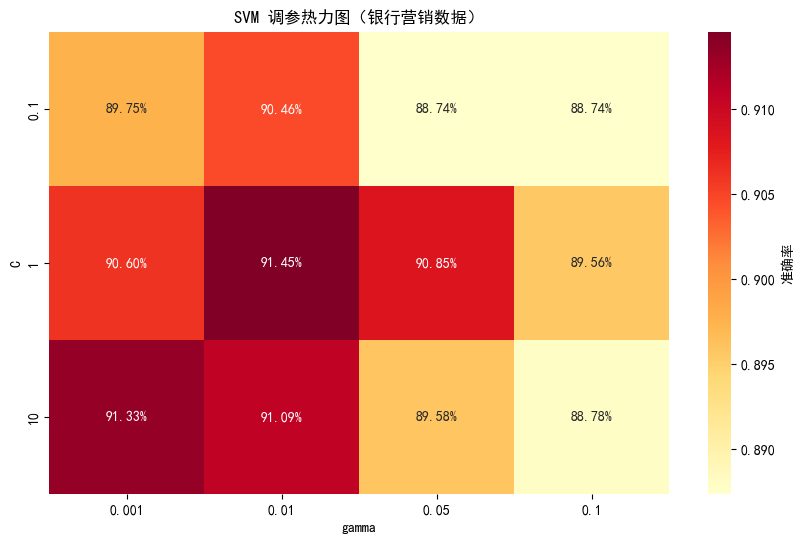

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(heat_matrix, annot=True, fmt='.2%', xticklabels=gamma_list, yticklabels=C_list, cmap='YlOrRd', cbar_kws={'label': '准确率'})
plt.xlabel('gamma')
plt.ylabel('C')
plt.title('SVM 调参热力图（银行营销数据）')
plt.show()